In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("saas.csv")

In [3]:
df.head(2)

,user_id,name,email,signup_date,country,plan_at_signup,sessions_30d,avg_session_min,feature_A_usage,feature_B_usage,emails_opened_30d,last_active_days_ago,lifetime_days,converted_to_paid,churned,mrr,churned_recently
0,user_00001,Denise Walker,jpeterson@gmail.com,2025-08-02,US,free,2,12.3,1.91,1.0,1,23,83,0,0,0.00,0
1,user_00002,James Howard,elizabethmiles@hotmail.com,2022-08-17,IN,pro,6,8.3,2.59,2.6,4,23,1164,1,0,108.73,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               5000 non-null   object 
 1   name                  5000 non-null   object 
 2   email                 5000 non-null   object 
 3   signup_date           5000 non-null   object 
 4   country               5000 non-null   object 
 5   plan_at_signup        5000 non-null   object 
 6   sessions_30d          5000 non-null   int64  
 7   avg_session_min       5000 non-null   float64
 8   feature_A_usage       5000 non-null   float64
 9   feature_B_usage       5000 non-null   float64
 10  emails_opened_30d     5000 non-null   int64  
 11  last_active_days_ago  5000 non-null   int64  
 12  lifetime_days         5000 non-null   int64  
 13  converted_to_paid     5000 non-null   int64  
 14  churned               5000 non-null   int64  
 15  mrr                  

In [5]:
df.isna().sum()

user_id                 0
name                    0
email                   0
signup_date             0
country                 0
plan_at_signup          0
sessions_30d            0
avg_session_min         0
feature_A_usage         0
feature_B_usage         0
emails_opened_30d       0
last_active_days_ago    0
lifetime_days           0
converted_to_paid       0
churned                 0
mrr                     0
churned_recently        0
dtype: int64

In [6]:
df.shape

(5000, 17)

In [7]:
df.columns

Index(['user_id', 'name', 'email', 'signup_date', 'country', 'plan_at_signup',
       'sessions_30d', 'avg_session_min', 'feature_A_usage', 'feature_B_usage',
       'emails_opened_30d', 'last_active_days_ago', 'lifetime_days',
       'converted_to_paid', 'churned', 'mrr', 'churned_recently'],
      dtype='object')

<Axes: xlabel='churned'>

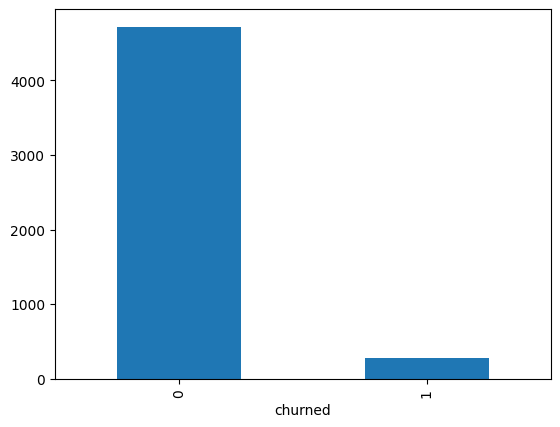

In [9]:
df['churned'].value_counts().plot(kind='bar')

In [11]:
df.dtypes

user_id                  object
name                     object
email                    object
signup_date              object
country                  object
plan_at_signup           object
sessions_30d              int64
avg_session_min         float64
feature_A_usage         float64
feature_B_usage         float64
emails_opened_30d         int64
last_active_days_ago      int64
lifetime_days             int64
converted_to_paid         int64
churned                   int64
mrr                     float64
churned_recently          int64
dtype: object

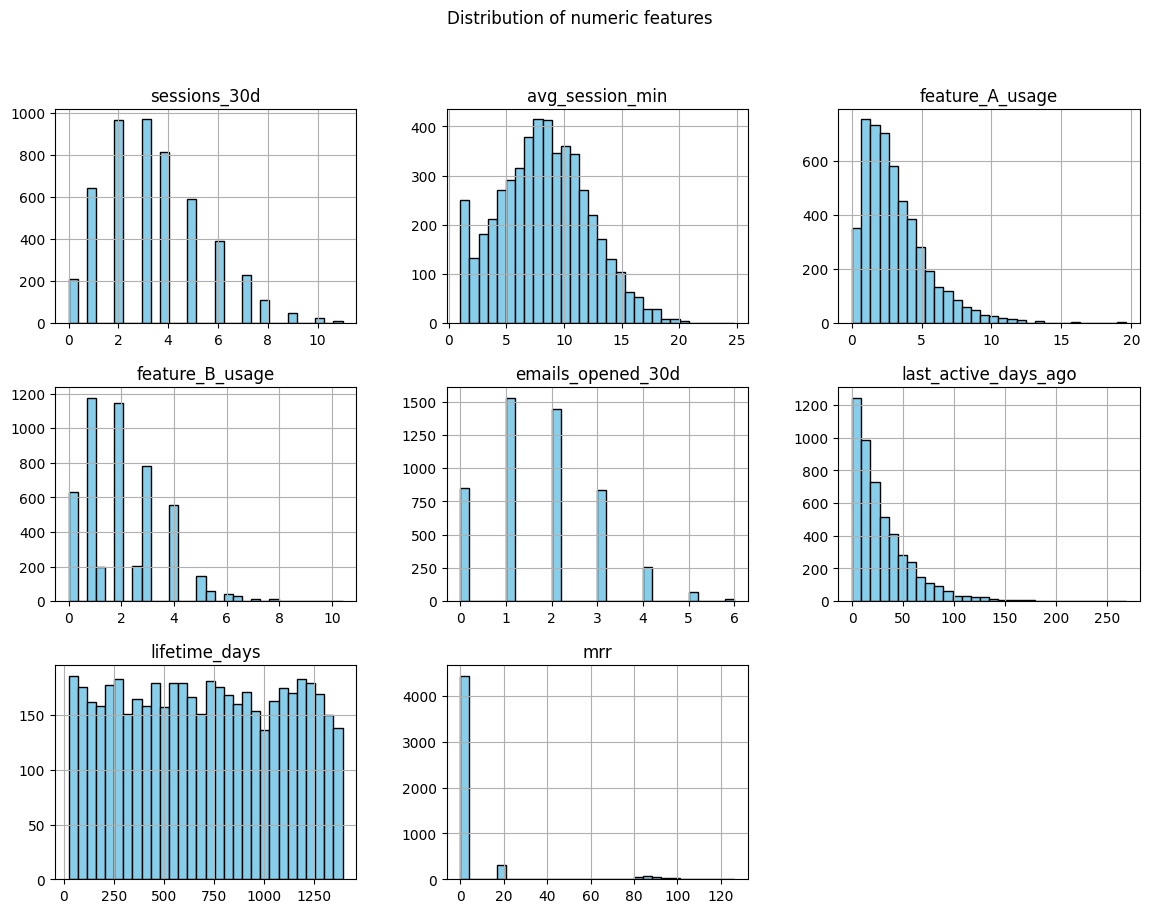

In [18]:
num_cols = [
    'sessions_30d','avg_session_min',"feature_A_usage", 'feature_B_usage','emails_opened_30d', 'last_active_days_ago', 
    'lifetime_days','mrr'
]
df[num_cols].hist(figsize=(14,10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of numeric features")
plt.show()

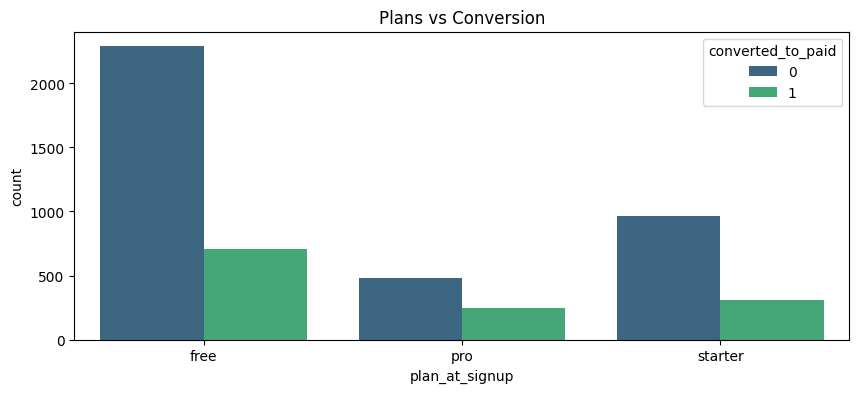

In [19]:
import seaborn as sns
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='plan_at_signup', hue='converted_to_paid', palette='viridis')
plt.title("Plans vs Conversion")
plt.show()

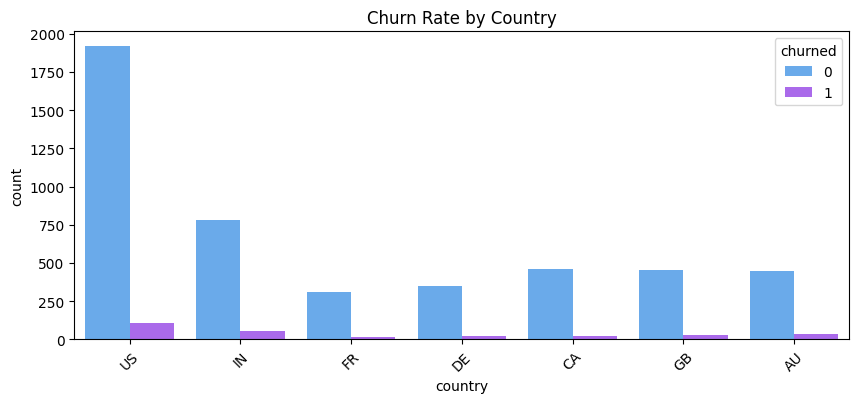

In [20]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='country', hue='churned', palette='cool')
plt.title("Churn Rate by Country")
plt.xticks(rotation=45)
plt.show()

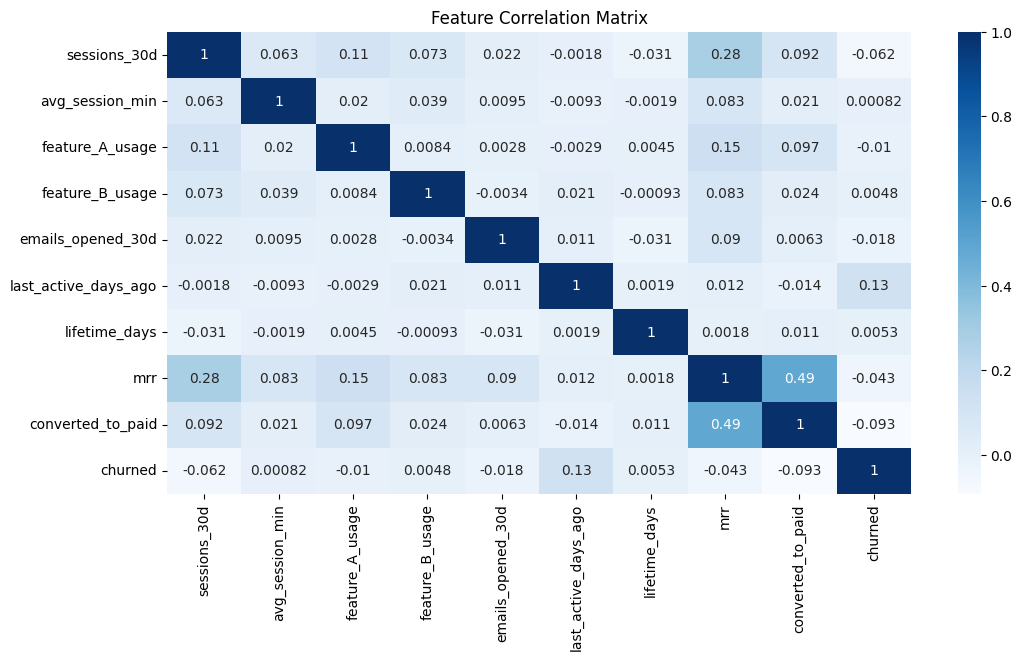

In [21]:
plt.figure(figsize=(12,6))
sns.heatmap(df[num_cols + ['converted_to_paid','churned']].corr(), annot=True, cmap='Blues')
plt.title("Feature Correlation Matrix")
plt.show()

/var/folders/m3/bdkhybqj6zg9q76kpypf11p00000gn/T/ipykernel_83276/1306535108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='converted_to_paid', y='sessions_30d', palette='Set2')


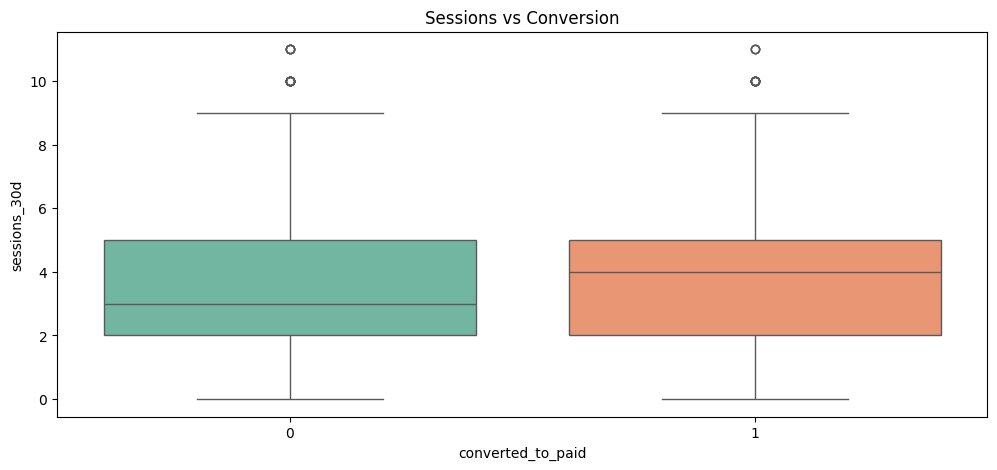

/var/folders/m3/bdkhybqj6zg9q76kpypf11p00000gn/T/ipykernel_83276/1306535108.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y='last_active_days_ago', palette='Set1')


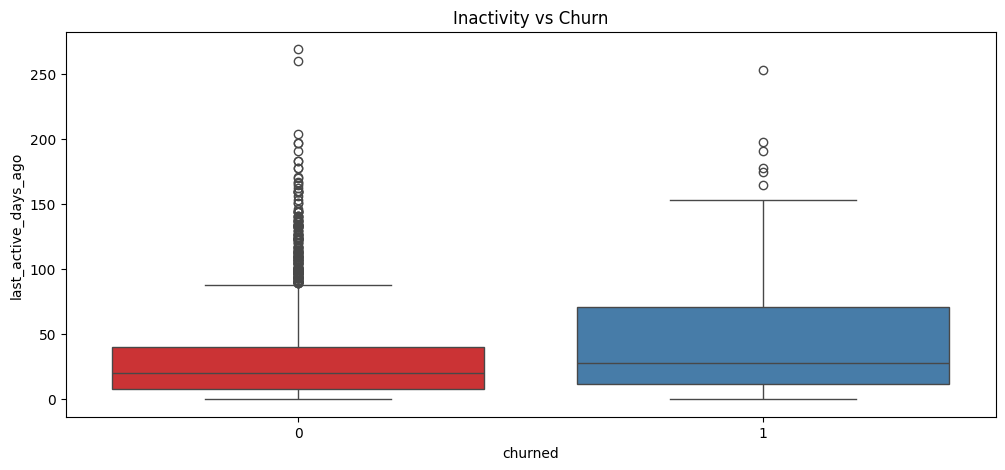

In [22]:
# Boxplots for feature vs conversion
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='converted_to_paid', y='sessions_30d', palette='Set2')
plt.title("Sessions vs Conversion")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='churned', y='last_active_days_ago', palette='Set1')
plt.title("Inactivity vs Churn")
plt.show()


MRR by Plan:
                      mean       sum  count
plan_at_signup                            
pro             30.559603  22308.51    730
starter          4.862313   6180.00   1271
free             0.000000      0.00   2999

Conversion & Churn by Country:
          converted_to_paid   churned
country                             
US                0.267160  0.052346
AU                0.253112  0.072614
GB                0.252066  0.064050
CA                0.248963  0.045643
DE                0.242588  0.053908
FR                0.235294  0.049536
IN                0.234094  0.062425


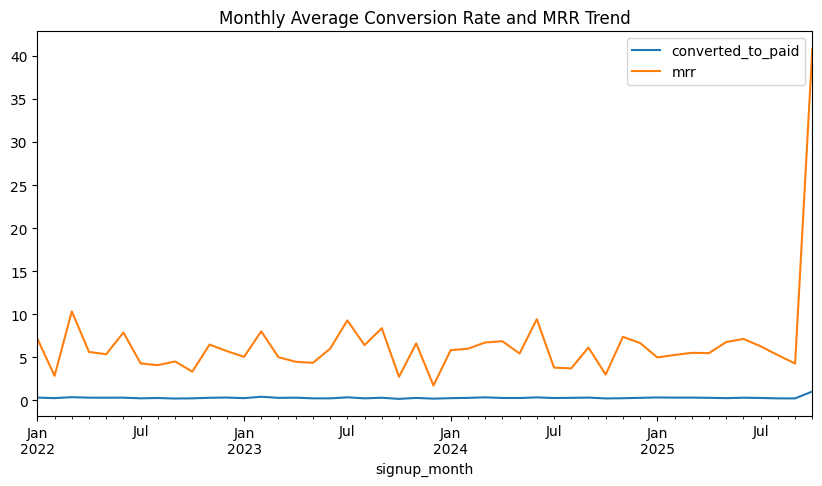

In [24]:

mrr_by_plan = df.groupby('plan_at_signup')['mrr'].agg(['mean','sum','count']).sort_values('sum', ascending=False)
print("\nMRR by Plan:\n", mrr_by_plan)
summary_country = df.groupby('country')[['converted_to_paid','churned']].mean().sort_values('converted_to_paid', ascending=False)
print("\nConversion & Churn by Country:\n", summary_country)

df['signup_month'] = pd.to_datetime(df['signup_date']).dt.to_period('M')
trend = df.groupby('signup_month')[['converted_to_paid','mrr']].mean()
trend.plot(figsize=(10,5), title="Monthly Average Conversion Rate and MRR Trend")
plt.show()


<Axes: xlabel='converted_to_paid'>

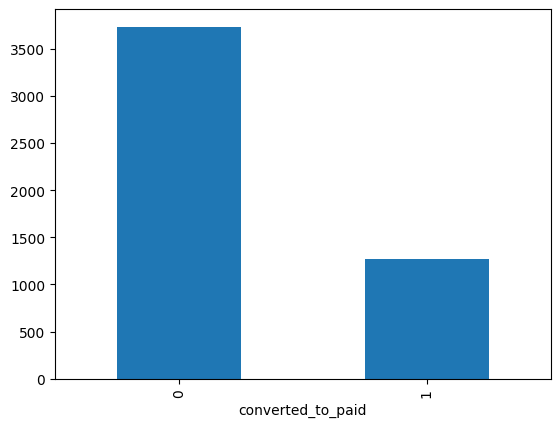

In [26]:
df['converted_to_paid'].value_counts().plot(kind='bar')

In [27]:
df.skew(numeric_only=True).sort_values(ascending=False)

churned_recently        5.838256
mrr                     3.851092
churned                 3.846966
last_active_days_ago    2.009369
feature_A_usage         1.647915
converted_to_paid       1.135459
feature_B_usage         0.837181
sessions_30d            0.614209
emails_opened_30d       0.529021
avg_session_min         0.172440
lifetime_days           0.010377
dtype: float64

In [32]:
df.groupby('plan_at_signup')['converted_to_paid'].mean()
df.groupby('plan_at_signup')['churned'].mean()

plan_at_signup
free       0.058019
pro        0.057534
starter    0.051928
Name: churned, dtype: float64